In [1]:
import pandas as pd
print("Task 1 — Data Exploration with Pandas\n")
print("---- Student Data Analysis ----\n")

# loading dataset
student_data = pd.read_csv("students.csv")

# just checking first few rows
print("Preview of data:\n")
print(student_data.head())

# checking size of dataset
rows, cols = student_data.shape
print(f"\nTotal rows: {rows}, Total columns: {cols}")

# data types of each column
print("\nColumn types:\n")
print(student_data.dtypes)

# quick statistics overview
print("\nBasic statistics:\n")
print(student_data.describe())

# count pass vs fail students
print("\nPass vs Fail count:\n")
print(student_data['passed'].value_counts())

# Average scores comparison

subjects = ['math', 'science', 'english', 'history', 'pe']

# filtering students
passed_students = student_data[student_data['passed'] == 1]
failed_students = student_data[student_data['passed'] == 0]

print("\nAverage marks of passing students:\n")
print(passed_students[subjects].mean())

print("\nAverage marks of failing students:\n")
print(failed_students[subjects].mean())

# Finding top student

# calculating average marks for each student
student_data['avg_marks'] = student_data[subjects].mean(axis=1)

# getting row with highest average
top_student = student_data.loc[student_data['avg_marks'].idxmax()]

print("\nTop performer:")
print(f"{top_student['name']} with average {round(top_student['avg_marks'], 2)}")

Task 1 — Data Exploration with Pandas

---- Student Data Analysis ----

Preview of data:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Total rows: 15, Total columns: 9

Column types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed     

Task 2 — Data Visualization with Matplotlib



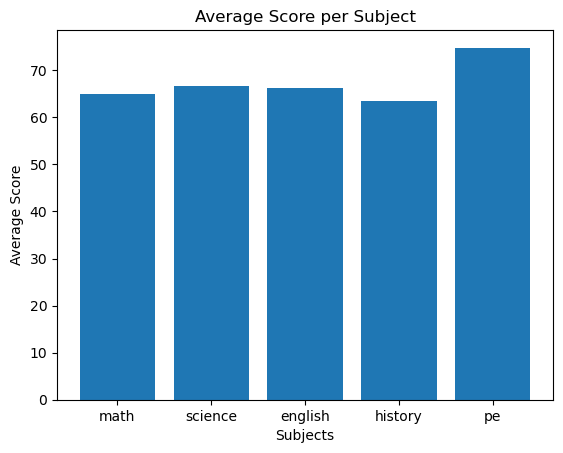

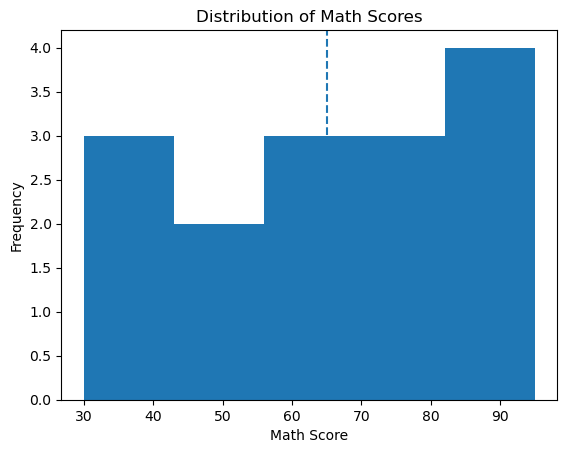

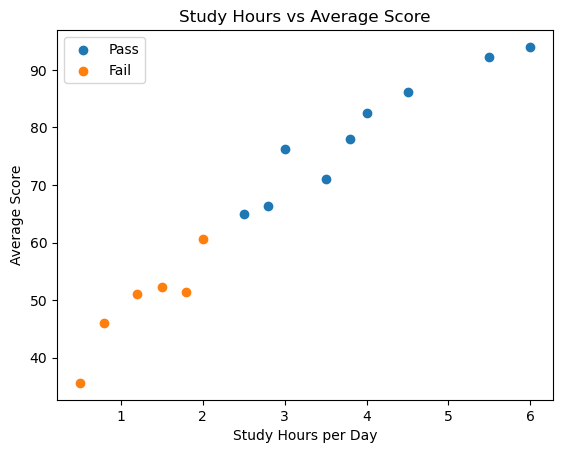

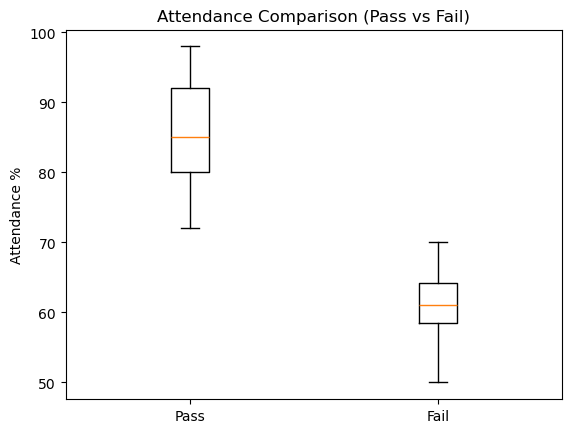

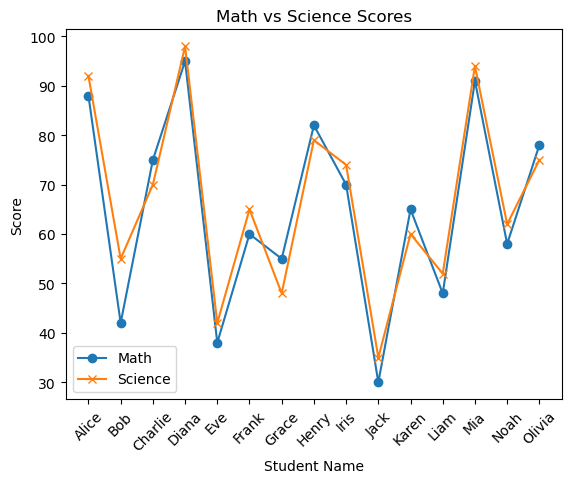

In [2]:
print("Task 2 — Data Visualization with Matplotlib\n")
import pandas as pd
import matplotlib.pyplot as plt

# loading data
df = pd.read_csv("students.csv")

# subjects list
subjects = ['math', 'science', 'english', 'history', 'pe']

# adding average column
df['avg_score'] = df[subjects].mean(axis=1)

# 1. Bar Chart

avg_scores = df[subjects].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()


# 2. Histogram (Math Scores)

plt.figure()
plt.hist(df['math'], bins=5)

# mean line
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed')

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.savefig("plot2_hist.png")
plt.show()


# 3. Scatter Plot

pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


# 4. Box Plot

pass_attendance = pass_data['attendance_pct'].tolist()
fail_attendance = fail_data['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Comparison (Pass vs Fail)")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()


# 5. Line Plot

plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

In [3]:
import micropip
await micropip.install("seaborn")

Task 3 — Data Visualization with Seaborn



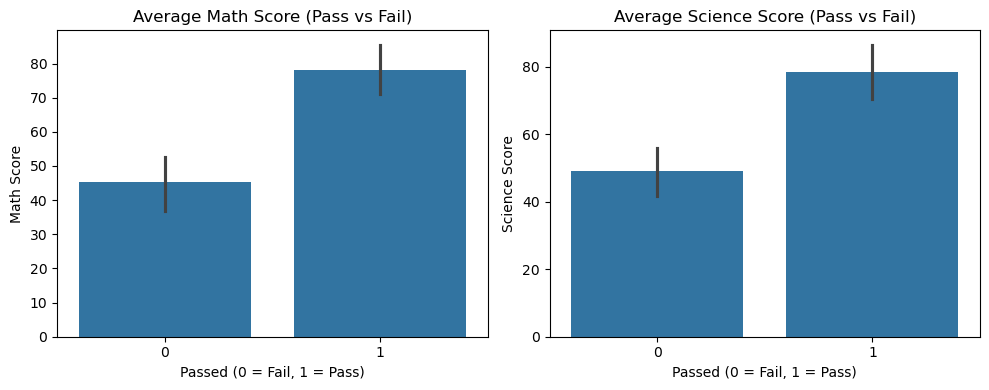

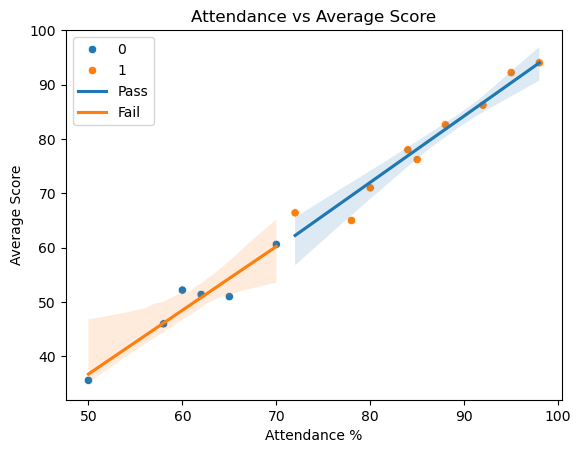

In [4]:
print("Task 3 — Data Visualization with Seaborn\n")
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# loading data
df = pd.read_csv("students.csv")

# creating avg_score again (in case not present)
subjects = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subjects].mean(axis=1)

# 1. Bar Plot (Math & Science)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# math scores
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# science scores
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


# 2. Scatter + Regression

plt.figure()

# pass students
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# Comparison Comment

# Seaborn made it easier to create cleaner and more attractive plots with less code,
# especially for grouped data like pass vs fail. In matplotlib, more manual work was
# needed for styling and grouping, while seaborn handled it automatically.

Task 4 — Machine Learning with scikit-learn 

Training Accuracy: 1.0

Test Accuracy: 1.0

Test Predictions:

Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct

Feature Importance:

english: 0.813
attendance_pct: 0.522
study_hours_per_day: 0.484
pe: 0.475
math: 0.438
science: 0.323
history: 0.263


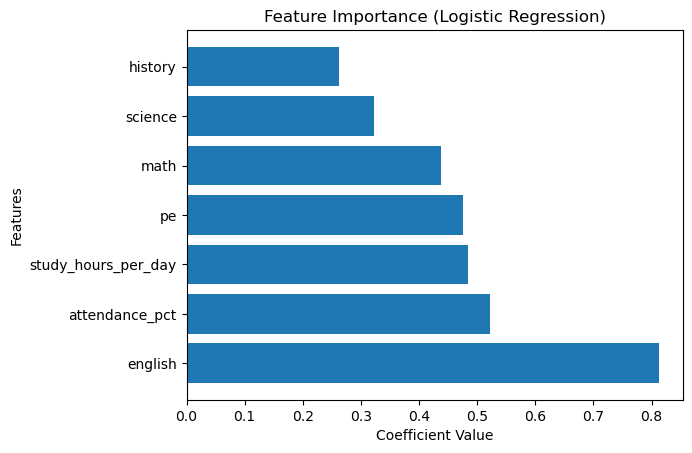


New Student Prediction:
Result: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


In [5]:
print("Task 4 — Machine Learning with scikit-learn \n")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Load data

df = pd.read_csv("students.csv")

# features and target
features = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']
X = df[features]
y = df['passed']

# Step 1 — Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2 — Train Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", round(train_acc, 2))

# Step 3 — Evaluate Model

y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", round(test_acc, 2))

print("\nTest Predictions:\n")

# getting student names using index
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")

# Step 4 — Feature Importance

coefficients = model.coef_[0]

# pairing feature with coefficient
feature_importance = list(zip(features, coefficients))

# sorting by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:\n")
for f, c in feature_importance:
    print(f"{f}: {round(c, 3)}")

# plotting
names = [f for f, _ in feature_importance]
values = [c for _, c in feature_importance]

colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()
plt.barh(names, values)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.savefig("plot8_feature_importance.png")
plt.show()

# Step 5 — New Student Prediction

new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=features   # very important
)

new_scaled = scaler.transform(new_student)
prediction = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print("Result:", result)
print("Probability (Fail, Pass):", prob)